In [8]:
from __future__ import division, print_function

import ROOT

import os, sys
import math
import collections
import copy
import json

ANA_DIR = os.path.expanduser("~/nobackup/bbtautau_afresh/CMSSW_15_0_15/src/Ana")
os.chdir(ANA_DIR)
sys.path.insert(0, ANA_DIR)

ROOT.gInterpreter.AddIncludePath(ANA_DIR)  
ROOT.gROOT.LoadMacro("Particle.h+")
ROOT.gROOT.LoadMacro("HHbbtautauAnaElements.C+")

print("CWD =", os.getcwd())
print("sys.path[0] =", sys.path[0])

ROOT.gErrorIgnoreLevel = ROOT.kInfo  # show more
# ROOT.ROOT.EnableImplicitMT(0)        # avoid MT confusing errors

import anaConfig
from ROOT import Ana, TCanvas, TH1D, TPad, TLegend, THStack, RDataFrame
from argparse import ArgumentParser


CWD = /uscms_data/d3/adas1/bbtautau_afresh/CMSSW_15_0_15/src/Ana
sys.path[0] = /uscms/home/adas1/nobackup/bbtautau_afresh/CMSSW_15_0_15/src/Ana


Info in <ACLiC>: unmodified script has already been compiled and loaded
Info in <ACLiC>: unmodified script has already been compiled and loaded


In [3]:
filedict = {"sigggF": "/eos/home-m/mhuwiler/data/HHtobbtautau/NanoAODv15/signalggF.root", }
# Ana.filemanager.AddItem("sigggF", "/eos/home-m/mhuwiler/data/HHtobbtautau/NanoAODv15/signalggF.root", "Events")
# Ana.filemanager.AddItem("official", "/eos/home-m/mhuwiler/data/HHtobbtautau/NanoAODv12/Run3Summer22NanoAODv12_1-1.root", "Events")
# Ana.filemanager.AddItem("ggfBoostedPrivate", "/eos/home-m/mhuwiler/software/rh9/AnaBoosted/data/Run3_2023_BoostedPrivate/glugluHHto2b2tau/ggf.root", "Events")
# Ana.filemanager.AddItem("VBFBoostedPrivate", "/eos/home-m/mhuwiler/software/rh9/AnaBoosted/data/Run3_2023_BoostedPrivate/VBFHHto2b2tau/VBF_SM.root", "Events")
# Ana.filemanager.AddItem("QCDBoostedPrivate", "/eos/home-m/mhuwiler/software/rh9/AnaBoosted/data/Run3_2023_BoostedPrivate/QCD/qcd_HT_100-1200.root", "Events")
# Ana.filemanager.AddItem("VBFBoostedPrivate", "/eos/home-m/mhuwiler/software/rh9/AnaBoosted/data/Run3_2023_BoostedPrivate/dataset/jetmet.root", "Events")

Ana.filemanager.AddItem(
    "ggfBoostedPrivate",
	"root://cmseos.fnal.gov//store/user/lpcdihiggsboost/NanoAOD_v12_ParT/rkansal/2022/HHbbtt/GluGlutoHHto2B2Tau_kl-0p00_kt-1p00_c2-0p00_TuneCP5_13p6TeV_powheg-pythia8/GluGlutoHHto2B2Tau_kl-0p00_kt-1p00_c2-0p00_TuneCP5_13p6TeV/241029_185858/0000/Run3Summer22NanoAODv12_1-1.root",
    "Events"
)



True

In [ ]:
def loadFile(desc): 
	frame = ROOT.RDataFrame(Ana.filemanager.GetItem(desc, True))
	ROOT.SetOwnership(frame, 0)
	return generalise(frame)

def loadFileFull(desc, writemode = False, treename = "Events"): 
	path = filedict[desc]
	flag = "WRITE" if writemode else "READ" 
	file = ROOT.TFile.Open(path, flag)
	tree = copy.deepcopy(file.Get(treename))
	tree.Print()
	frame = ROOT.RDataFrame(tree)
	print(frame)
	ROOT.SetOwnership(frame, 0)
	return frame

def dropBranchNames(frame, filename, exclusionlist = []):
	"""
	Writes a list of column (branch) names from a ROOT RDataFrame to a text file,
	excluding any branches whose names contain substrings in the exclusion list.

	Parameters:
		frame         : ROOT.RDataFrame
			The dataframe to extract column names from.
		filename      : str
			The name of the output text file where the column names will be saved.
		exclusionlist : list of str
			List of substrings; any column containing these substrings will be excluded.
	"""
	with open(filename, "w") as file: 
		for name in frame.GetColumnNames(): 
			name = str(name)
			#print("{} {}".format(name, [(excluded in name) for excluded in exclusionlist]))
			if not (any([excluded in name for excluded in exclusionlist])): 
				file.write("{}\n".format(name))

def generalise(df): 
	return ROOT.ROOT.RDF.AsRNode(df)


In [ ]:
def get_options(arg_list=None):
    parser = ArgumentParser(description="Selection")
    parser.add_argument("-c", "--version", dest="version", type=str, default="v7")
    parser.add_argument("--prefix", dest="xrdpfx", type=str, default="root://cms-xrd-global.cern.ch//")
    parser.add_argument("-o", "--out", dest="outputpath", type=str, default="./temp")
    parser.add_argument("--debug", dest="debug", action="store_true", default=False)
    parser.add_argument("--test", dest="test", action="store_true", default=False)
    parser.add_argument("-b", "--batch", dest="batch", action="store_true", default=False)

    # If arg_list is None, use empty list (not sys.argv)
    return parser.parse_args(args=[] if arg_list is None else arg_list)

options = get_options(["--test"]) 

	
if (options.batch): 
	ROOT.gROOT.SetBatch(1) 

if not hasattr(ROOT, "__ANA_INIT_DONE__"):
    Ana.Init()
    ROOT.__ANA_INIT_DONE__ = True


ROOT.ROOT.DisableImplicitMT()

#ROOT.gSystem.Load("HHbbtautauAnaELements.so")
#ROOT.gSystem.Load("MyDict.so")


sig = loadFile("ggfBoostedPrivate")

if (options.test): 
	sig = generalise(sig.Range(0, 5000))

ROOT.gStyle.SetOptStat(0)
ROOT.RDF.Experimental.AddProgressBar(sig)
print(sig)


<cppyy.gbl.ROOT.RDF.RInterface<ROOT::Detail::RDF::RNodeBase,void> object at 0x2bbd2520>


Warning in <ROOT_TImplicitMT_DisableImplicitMT>: Implicit multi-threading is already disabled


In [29]:
# Creates file with the name branchnames.txt
dropBranchNames(sig, "branchnames.txt", ["L1", "HLT", "DST"])

In [30]:
#sig = Ana.GetP4(sig, "Muon") #sig = Ana.GetP4["float"](sig, "Muon")
#sig = Ana.GetGenParticles(sig, "Muon")
#sig = Ana.GetGenParticles(sig, "Electron")

genprefix = "GenPart"

cutflow = ROOT.CutFlow("cutflow", "Selection cutflow")

n0 = sig.Count().GetValue()
cutflow.Increment("Initial", n0)

sig = sig.Filter("nFatJet>=2").Filter("FatJet_pt[0]>250&&FatJet_pt[1]>200")

n1 = sig.Count().GetValue()
cutflow.Add("jet selection", n1)

print(n0, n1)

5000 152


In [ ]:
sig = sig.Define("GenDecay", "Ana::DecayGenMatching({0}_pdgId, {0}_genPartIdxMother, {0}_statusFlags)".format("GenPart"))
#sig = sig.Define("TheGenMuon_pt", "Ana::overflowProtected(GenPart_pt, GenDecay.mu)").Define("TheGenMuon_eta", "GenPart_eta[GenDecay.mu]").Define("TheGenMuon_phi", "GenPart_phi[GenDecay.mu]")
sig = sig.Define("dR_mu_gen", "Ana::deltaR(GenDecay.mu, {0}_pt, {0}_eta, {0}_phi, {0}_mass, {1}_pt, {1}_eta, {1}_phi, {1}_mass, {1}_pdgId, \"{1}\")".format("GenPart", "Muon"))
sig = sig.Define("closest_mu_gen", "Ana::closestMatch(GenDecay.mu, {0}_pt, {0}_eta, {0}_phi, {0}_mass, {1}_pt, {1}_eta, {1}_phi, {1}_mass, {1}_pdgId, \"{1}\")".format("GenPart", "Muon"))
sig = sig.Define("closest_mu_FatJet", "Ana::closestMatch(GenDecay.mu, {0}_pt, {0}_eta, {0}_phi, {0}_mass, {1}_pt, {1}_eta, {1}_phi, {1}_mass)".format("GenPart", "FatJet"))
sig = sig.Define("dR_mu_FatJet", "Ana::deltaR(GenDecay.mu, {0}_pt, {0}_eta, {0}_phi, {0}_mass, {1}_pt, {1}_eta, {1}_phi, {1}_mass)".format("GenPart", "FatJet"))
sig = sig.Define("dR_HH", "Ana::deltaR(GenDecay.Htotau, {0}_pt, {0}_eta, {0}_phi, {0}_mass, {0}_pt, {0}_eta, {0}_phi, {0}_mass, GenDecay.Htob)".format("GenPart"))
sig = sig.Define("dR_tautau", "Ana::deltaR(GenDecay.tau1, {0}_pt, {0}_eta, {0}_phi, {0}_mass, {0}_pt, {0}_eta, {0}_phi, {0}_mass, GenDecay.tau2)".format("GenPart"))

hh = sig.Filter("GenDecay.decayType==1")
hm = sig.Filter("GenDecay.decayType==2")
n2 = hm.Count().GetValue()
cutflow.Add("tauh taumu", n2)

hm = hm.Define("dR_mu_FatJet_hm", "Ana::deltaR(GenDecay.mu, {0}_pt, {0}_eta, {0}_phi, {0}_mass, {1}_pt, {1}_eta, {1}_phi, {1}_mass)".format("GenPart", "FatJet"))
hi = hm.Filter("dR_mu_FatJet_hm<0.8&&dR_mu_FatJet_hm>0")
n3 = hi.Count().GetValue()
cutflow.Add("gen mu in jet", n3)

hi = hi.Define("TheRecoMuon", "closest_mu_gen")
hi = hi.Define("TheRecoMuon_pt", "Muon_pt[TheRecoMuon]")
hi = hi.Filter("Muon_tightId[TheRecoMuon]")
n4 = hi.Count().GetValue()
cutflow.Add("reco mu matched", n4)

hi = hi.Filter("Muon_pt[TheRecoMuon]>20&&abs(Muon_eta[TheRecoMuon])<2.4&&Muon_dz[TheRecoMuon]<0.2&&Muon_dxy[TheRecoMuon]<0.05")
n5 = hi.Count().GetValue()
cutflow.Add("muon sel", n5)

#hh = hh.Define("dR_tautau", "Ana::deltaR(GenDecay.tau1, {0}_pt, {0}_eta, {0}_phi, {0}_mass, {0}_pt, {0}_eta, {0}_phi, {0}_mass, GenDecay.tau2)".format("GenPart"))

In [34]:
blacklist = ["Muon_P4", "GenPart_Particle", "GenMuon", "HLT*", "L1*"] # TODO: add autoblacklist

sig.Snapshot("Events", "./SigAll.root", Ana.purgeColumns(sig.GetColumnNames(), blacklist))
hh.Snapshot("Events", "./Sighh.root", Ana.purgeColumns(hh.GetColumnNames(), blacklist))
hm.Snapshot("Events", "./Sighm.root", Ana.purgeColumns(hm.GetColumnNames(), blacklist))
hi.Snapshot("Events", "./Sigwithproxy.root", Ana.purgeColumns(hi.GetColumnNames(), blacklist))

print("Initial: {}, 2 FatJets: {}, tauhtaumu: {}, gen mu within jet: {}, reco mu within jet: {}, other selection requirements: {}".format(n0, n1, n2, n3, n4, n5))

<cppyy.gbl.ROOT.RDF.RResultPtr<ROOT::RDF::RInterface<ROOT::Detail::RDF::RLoopManager,void> > object at 0x3a6a5190>

N bs: 2
N bs: 2
N bs: 2
N taus: 1, N Higgses: 1
N taus: 2
Tau: 15 (id), Higgs (mother = 25), 12675 (status)
Tau: -15 (id), Higgs (mother = 25), 12675 (status)
N bs: 2
N taus: 1, N Higgses: 1
N taus: 2
Tau: 15 (id), Higgs (mother = 25), 12675 (status)
Tau: -15 (id), Higgs (mother = 25), 12675 (status)
N bs: 2
N taus: 1, N Higgses: 1
N taus: 2
Tau: 15 (id), Higgs (mother = 25), 12675 (status)
Tau: -15 (id), Higgs (mother = 25), 12675 (status)
N bs: 2
N taus: 1, N Higgses: 1
N taus: 2
Tau: 15 (id), Tau (mother = 15), 8451 (status)
Tau: -15 (id), Tau (mother = -15), 8451 (status)
N bs: 2
N taus: 1, N Higgses: 1
N taus: 2
Tau: 15 (id), Tau (mother = 15), 8451 (status)
Tau: -15 (id), Tau (mother = -15), 8451 (status)
N bs: 2
N bs: 2
N taus: 1, N Higgses: 1
N taus: 2
Tau: 15 (id), Higgs (mother = 25), 12675 (status)
Tau: -15 (id), Higgs (mother = 25), 12675 (status)
N taus: 1, N Higgses: 0
N bs: 2
N bs: 2
N taus: 1, N Higgses: 1
N taus: 2
Tau: -15 (id), Tau (mother = -15), 8451 (status)
Tau: 

Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas


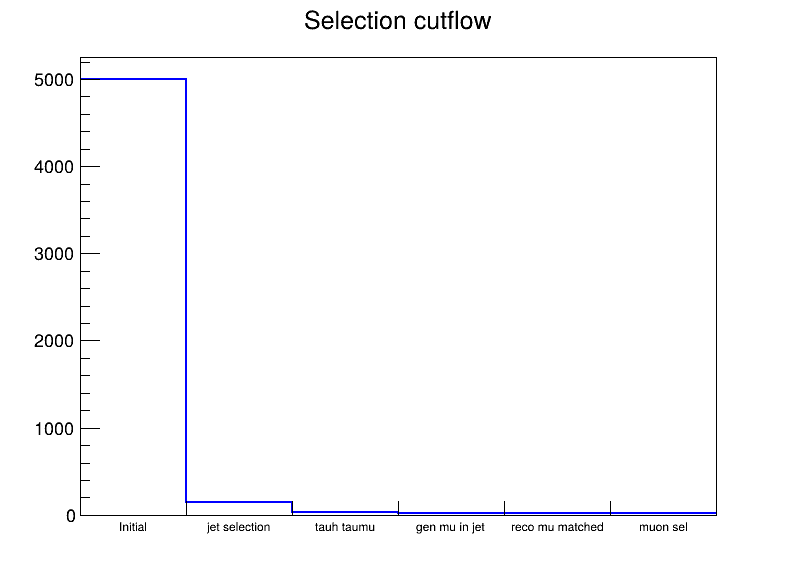

In [17]:
canvas = ROOT.TCanvas("canvas", "canvas", 800, 600)
histo = cutflow.GenerateHistogram()
histo.SetLineColor(ROOT.kBlue)
histo.SetLineWidth(2)
histo.Draw("HIST")
canvas.Update()      # important for interactive display

Warning in <TCanvas::Constructor>: Deleting canvas with same name: efficiencies


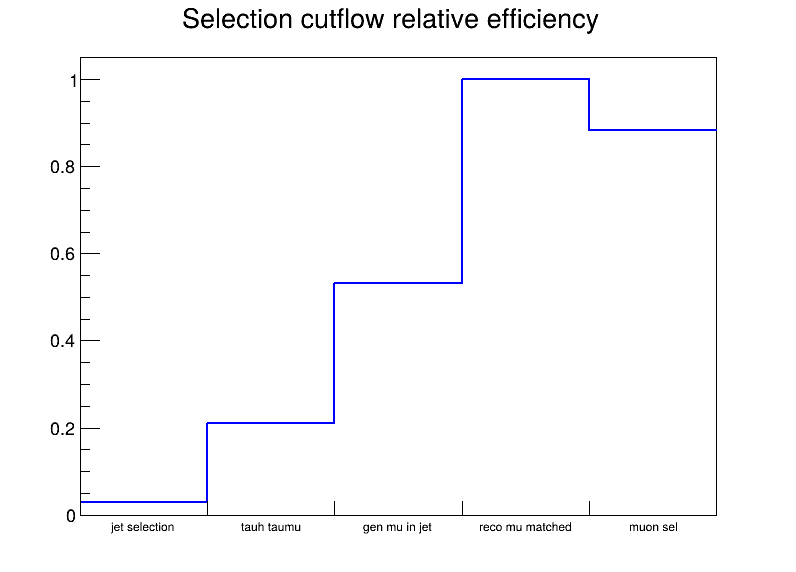

In [18]:
efficiencies = ROOT.TCanvas("efficiencies", "efficiencies", 800, 600)
eff = cutflow.MakeEffHistogram()
eff.SetLineColor(ROOT.kBlue)
eff.SetLineWidth(2)
eff.Draw("HIST")
efficiencies.Update()  # important for interactive display

In [ ]:
Ana.filemanager.CloseAll()